In [17]:
## 1. Importing Modules & Reading Data

In [1]:
import numpy as np
import pandas as pd
from osgeo import gdal, osr
import matplotlib.pyplot as plt


In [14]:
### 1.1 Training Dataset with training Labels

In [2]:
# open the GeoTIFF files using GDAL
ds_training_GT = gdal.Open(r"C:\Users\Bibhu\Desktop\LULC_Project\Data\S2A_MSIL1C_20220516_Train_GT.tif", gdal.GA_ReadOnly)

# read the data from the first GeoTIFF file into a NumPy array
train_GT_2d = ds_training_GT.ReadAsArray()
train_GT_2d = np.swapaxes(train_GT_2d, 0, 1)

# convert the 2D NumPy arrays into 2D arrays with rows and columns
train_GT_1d = train_GT_2d.reshape(train_GT_2d.shape[0] * train_GT_2d.shape[1], 1)

# convert the combined array into a Pandas dataframe
df_train_labels = pd.DataFrame(train_GT_1d)

# image size
count = ds_training_GT.RasterCount
img_width, img_height = ds_training_GT.RasterXSize, ds_training_GT.RasterYSize
crs = ds_training_GT.GetMetadataItem('product_crs')

print(f'Number of bands: {count}\nHeight: {img_height}\nWidth: {img_width}\nCRS: {crs}')

C:\Program Files\ArcGIS\Pro\bin\Python\envs\arcgispro-py3\lib\site-packages\osgeo\gdal.py:287: FutureWarning: Neither gdal.UseExceptions() nor gdal.DontUseExceptions() has been explicitly called. In GDAL 4.0, exceptions will be enabled by default.
  warnings.warn(


Number of bands: 1
Height: 1131
Width: 855
CRS: EPSG:4326


Height: 1131
Width: 855
Data type: 1
Min/max values: (10.0, 90.0)
Min/max/mean/std values: [10.0, 90.0, 64.28229816205446, 23.099381472974393]


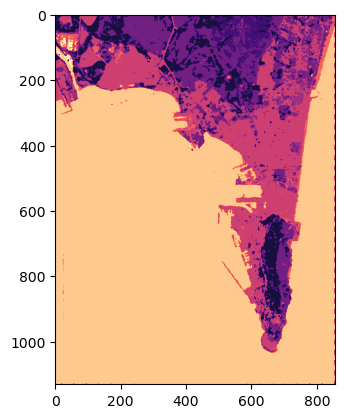

In [3]:
# band information
band = ds_training_GT.GetRasterBand(1)

print(f'Height: {band.YSize}\nWidth: {band.XSize}\nData type: {band.DataType}')
print(f'Min/max values: {band.ComputeRasterMinMax()}')
print(f'Min/max/mean/std values: {band.ComputeStatistics(0)}')

# plot image
band_array = band.ReadAsArray()
plt.imshow(band_array, cmap='magma')
plt.show()

In [4]:
# projection information from WKT
proj = osr.SpatialReference(wkt=ds_training_GT.GetProjectionRef())

print('EPSG:', proj.GetAttrValue('AUTHORITY', 1))
print('Zone:', proj.GetAttrValue('PROJCS', 0))

EPSG: 32630
Zone: WGS 84 / UTM zone 30N


In [5]:
ds_training_GT.GetMetadata()

{'algorithm_version': 'V2.0.0',
 'AREA_OR_POINT': 'Area',
 'copyright': 'ESA WorldCover project 2021 / Contains modified Copernicus Sentinel data (2021) processed by ESA WorldCover consortium',
 'creation_time': '2022-10-21 07:35:40.236136',
 'legend': '10  Tree cover\n20  Shrubland\n30  Grassland\n40  Cropland\n50  Built-up\n60  Bare/sparse vegetation\n70  Snow and ice\n80  Permanent water bodies\n90  Herbaceous wetland\n95  Mangroves\n100 Moss and lichen\n',
 'license': 'CC-BY 4.0 - https://creativecommons.org/licenses/by/4.0/',
 'product_crs': 'EPSG:4326',
 'product_grid': '3x3 degree tiling grid',
 'product_tile': 'N36W006',
 'product_type': 'LandCover Map',
 'product_version': 'V2.0.0',
 'reference': 'https://esa-worldcover.org',
 'time_end': '2021-12-31T23:59:59Z',
 'time_start': '2021-01-01T00:00:00Z',
 'title': 'ESA WorldCover product at 10m resolution for year 2021'}

In [6]:
'''
A geotransform consists in a set of 6 coefficients:
GT(0) x-coordinate of the upper-left corner of the upper-left pixel,
GT(1) w-e pixel resolution / pixel width,
GT(2) row rotation (typically zero),
GT(3) y-coordinate of the upper-left corner of the upper-left pixel,
GT(4) column rotation (typically zero),
GT(5) n-s pixel resolution / pixel height (negative value for a north-up image).
'''

GT = ds_training_GT.GetGeoTransform()

minx = GT[0]
miny = GT[3] + img_width * GT[4] + img_height * GT[5]
maxx = GT[0] + img_width * GT[1] + img_height * GT[2]
maxy = GT[3]

print(f'X min: {minx}\nY min: {miny}\nX max: {maxx}\nY max: {maxy}')

X min: 282160.0
Y min: 3997630.0
X max: 290710.0
Y max: 4008940.0


In [13]:
### 1.2 Training Dataset With Training Data

In [10]:
ds_training = gdal.Open("C:/Users/Bibhu/Desktop/LULC_Project/Data/S2A_MSIL1C_20220516_TrainingData.tif", gdal.GA_ReadOnly)

# read the data from the first GeoTIFF file into a NumPy array
data_training = ds_training.ReadAsArray()
data_training = np.swapaxes(data_training, 0, 2)

# convert the 2D NumPy arrays into 2D with rows and columns
data_training_1d = data_training.reshape(data_training.shape[0] * data_training.shape[1], -1)
df_train = pd.DataFrame(data_training_1d)

# create dataframe
final_data = pd.concat([df_train_labels, df_train])
train_label_data = pd.concat([df_train_labels, df_train], axis=1)
train_label_data.columns = ['Class', 'Blue', 'Green', 'Red', 'NIR']

# export dataframe to CSV file
#train_label_data.to_csv('train.csv', index=False)

# image size
count = ds_training.RasterCount
img_width, img_height = ds_training.RasterXSize, ds_training.RasterYSize

print(f'Number of bands: {count}\nHeight: {img_height}\nWidth: {img_width}')

Number of bands: 4
Height: 1131
Width: 855


Band-1
Min/max/mean/std values: [0.0, 10915.0, 2420.217324626036, 346.7068223591508]
Band-2
Min/max/mean/std values: [0.0, 11377.0, 2284.0169678543543, 402.35624265696106]
Band-3
Min/max/mean/std values: [0.0, 14103.0, 2233.2282790678437, 567.2224603639628]
Band-4
Min/max/mean/std values: [0.0, 15343.0, 2602.8054694649977, 887.3425007801084]


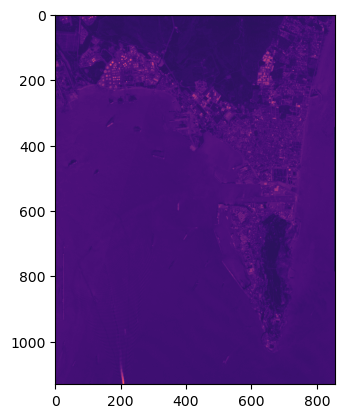

In [11]:

# information of each band
for i in range(1, 5):
    band = ds_training.GetRasterBand(i)
    print(f'Band-{i}')
    print(f'Min/max/mean/std values: {band.ComputeStatistics(0)}')
    
# plot image
band = ds_training.GetRasterBand(1)
band_array = band.ReadAsArray()
plt.imshow(band_array, cmap='magma')
plt.show()

In [12]:
### 1.3 Testing Dataset

In [15]:
ds_testing = gdal.Open(r"C:\Users\Bibhu\Desktop\LULC_Project\Data\S2B_MSIL1C_20220528_Test.tif", gdal.GA_ReadOnly)

# read the data from the first GeoTIFF file into a NumPy array
data_testing = ds_testing.ReadAsArray()
data_testing = np.swapaxes(data_testing, 0, 2)

# convert the 2D NumPy arrays into 2D arrays with rows and columns
data_testing_1d = data_testing.reshape(data_testing.shape[0] * data_testing.shape[1], -1)

# convert the combined array into a Pandas dataframe
df_test = pd.DataFrame(data_testing_1d, columns=['Blue', 'Green', 'Red', 'NIR'])

# export dataframe to CSV file
#df_test.to_csv('test.csv', index=False)

# image size
count = ds_testing.RasterCount
img_width, img_height = ds_testing.RasterXSize, ds_testing.RasterYSize

print(f'Number of bands: {count}\nHeight: {img_height}\nWidth: {img_width}')

Number of bands: 4
Height: 2001
Width: 2309


Band-1
Min/max/mean/std values: [0.0, 6747.0, 2134.583164459347, 315.2055007969227]
Band-2
Min/max/mean/std values: [0.0, 7127.0, 2061.257802670774, 411.6259118311492]
Band-3
Min/max/mean/std values: [0.0, 7874.0, 1920.5451579104342, 581.5019821553493]
Band-4
Min/max/mean/std values: [0.0, 7938.0, 3241.4306090783107, 1305.0949455862235]


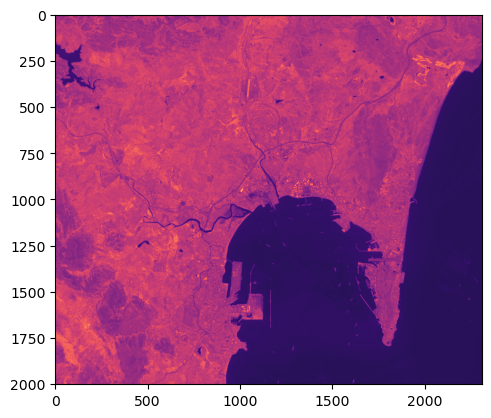

In [16]:
# information of each band
for i in range(1, 5):
    band = ds_testing.GetRasterBand(i)
    print(f'Band-{i}')
    print(f'Min/max/mean/std values: {band.ComputeStatistics(0)}')
    
# plot image
band = ds_testing.GetRasterBand(4)
band_array = band.ReadAsArray()
plt.imshow(band_array, cmap='magma')
plt.show()

In [18]:
## 2. Data Distribution of Bands

In [21]:
pip install earthpy pyrsgis

Defaulting to user installation because normal site-packages is not writeable
  Obtaining dependency information for earthpy from https://files.pythonhosted.org/packages/a7/72/98c78371de0ffd281d89f7da85bb2001aa6ce9820fabbfd2adfee99e1935/earthpy-0.9.4-py3-none-any.whl.metadata
  Obtaining dependency information for pyrsgis from https://files.pythonhosted.org/packages/a9/b4/d7bf0f3f309c7a816a1773068bd915bf4da80946b28b097f88ae6c8d72ff/pyrsgis-0.4.1-py3-none-any.whl.metadata
  Obtaining dependency information for rasterio from https://files.pythonhosted.org/packages/bd/e5/5a29b8b098067e8983b1592a3447d3928721d8ad3a7c4cee482e501942ee/rasterio-1.4.3-cp39-cp39-win_amd64.whl.metadata
  Obtaining dependency information for scikit-image from https://files.pythonhosted.org/packages/9d/63/233300aa76c65a442a301f9d2416a9b06c91631287bd6dd3d6b620040096/scikit_image-0.24.0-cp39-cp39-win_amd64.whl.metadata
  Obtaining dependency information for affine from https://files.pythonhosted.org/packages/0b/f7/85

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [22]:
import earthpy.plot as ep
import earthpy as et
import earthpy.spatial as es


from pyrsgis import raster

In [23]:
data = r"C:\Users\Bibhu\Desktop\LULC_Project\Data\S2A_MSIL1C_20220516_TrainingData.tif"
labels = r"C:\Users\Bibhu\Desktop\LULC_Project\Data\S2A_MSIL1C_20220516_Train_GT.tif"

# train data contains bands, test data contains labels
ds1, features_train = raster.read(data, bands='all')
ds2, features_test = raster.read(labels, bands ='all')

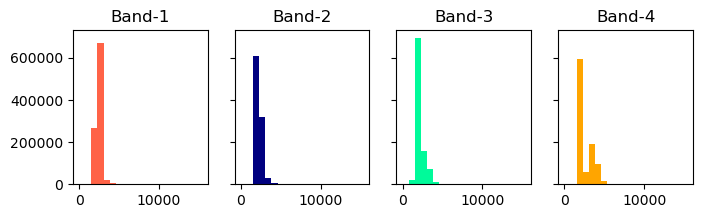

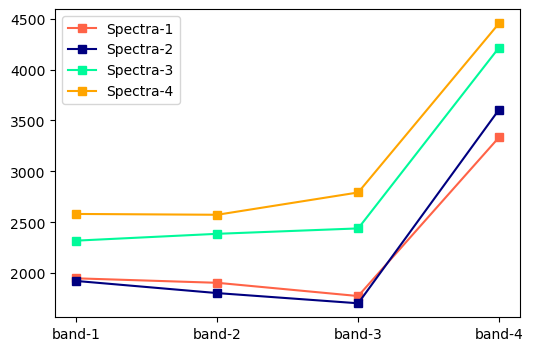

In [24]:
colors = ['tomato', 'navy', 'MediumSpringGreen', 'orange']

# histograms for each band
ep.hist(features_train, cols=4, colors=colors, title=[f'Band-{i}' for i in range(1, 5)], figsize=(8, 2))
plt.show()

# plot spectra for 3rd row
plt.figure(figsize=(6, 4))
for i, c in enumerate(colors):
    plt.plot(np.asarray(features_train[:, 2, i]), '-s', color=c, label= f'Spectra-{i+1}')
plt.xticks(range(4), [f'band-{i}' for i in range(1, 5)])
plt.legend()
plt.show()

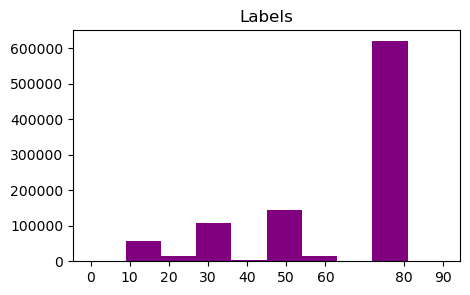

In [25]:
# histogram for class distribution
bins = len(np.unique(features_test))

ep.hist(features_test, title='Labels', bins=bins+1, figsize=(5, 3))
plt.xticks(np.unique(features_test).tolist())
plt.show()

In [26]:
classes, counts = np.unique(features_test, return_counts=True)

# class: 0 - undefined
pd.DataFrame(data={'Class': classes, 'Pixel Count': counts}).style.hide(axis='index')

Class,Pixel Count
0,1416
10,58025
20,15711
30,108276
40,4348
50,143396
60,15014
80,619074
90,1745


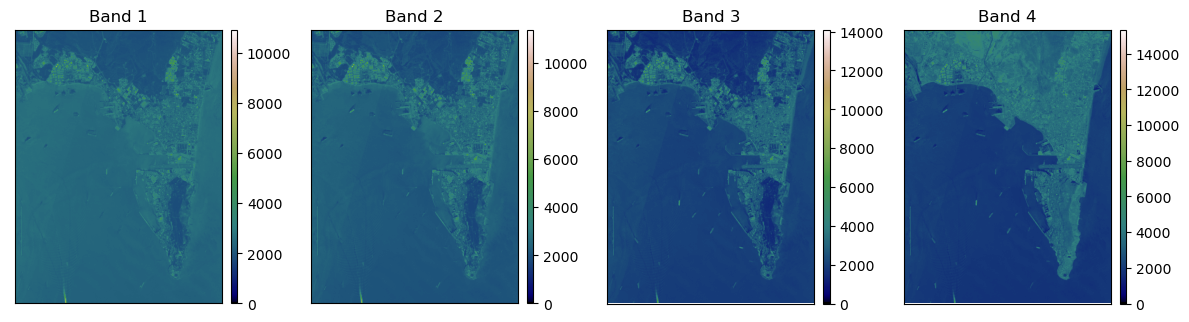

In [27]:
# plot each band
ep.plot_bands(features_train, cmap='gist_earth', cols=4)
plt.show()

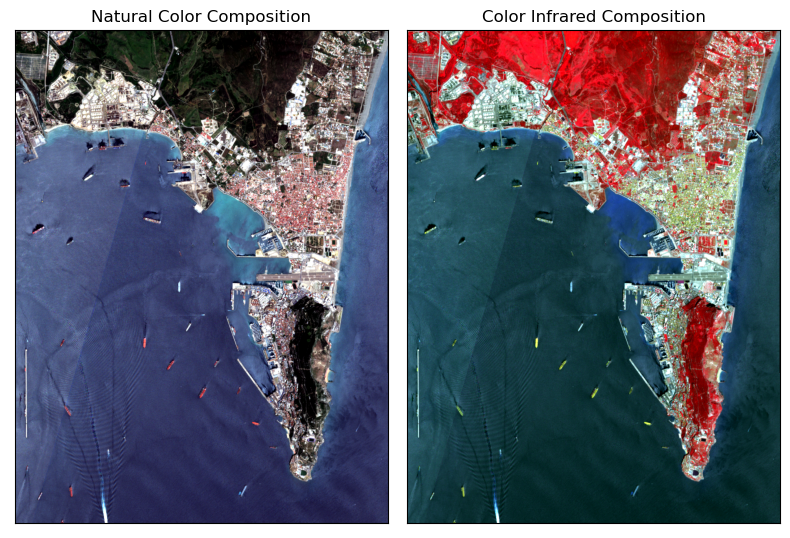

In [28]:
# band combinations
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 7))

# natural color (red, green, blue)
ax1 = ep.plot_rgb(features_train, rgb=(2, 1, 0), ax=ax1, stretch=True, title='Natural Color Composition')

# color infrared (NIR, red, green)
ax2 = ep.plot_rgb(features_train, rgb=(3, 2, 1), ax=ax2, stretch=True, title='Color Infrared Composition')

plt.tight_layout()
plt.show()

In [29]:
## 3. Vegetation Indices

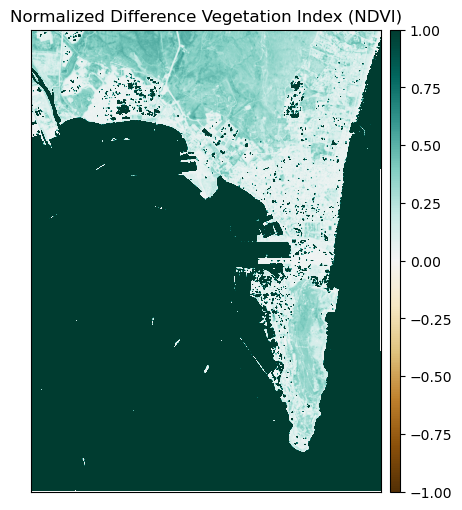

In [30]:
ndvi = (features_train[3] - features_train[2])/(features_train[3] + features_train[2])

title = 'Normalized Difference Vegetation Index (NDVI)'
ep.plot_bands(ndvi, cmap='BrBG', title=title, vmin=-1, vmax=1, figsize=(6, 6))

plt.show()

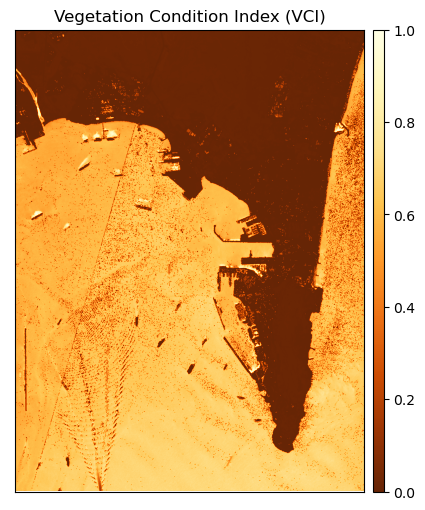

In [31]:
vci = (ndvi - np.nanmin(ndvi))/(np.nanmax(ndvi) - np.nanmin(ndvi))

title = 'Vegetation Condition Index (VCI)'
ep.plot_bands(vci, cmap='YlOrBr_r', title=title, vmin=0, vmax=1, figsize=(6, 6))

plt.show()

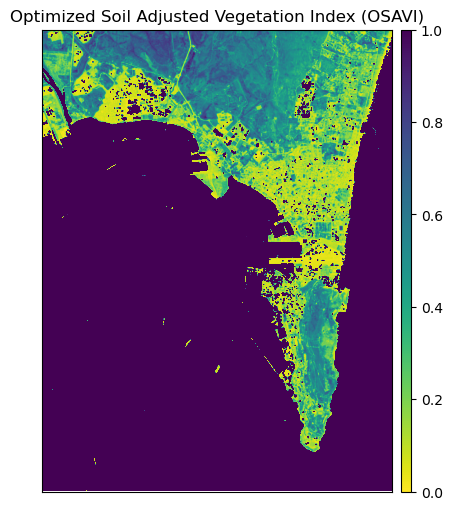

In [32]:
osavi = 1.6 * ((features_train[3] - features_train[2])/((features_train[3] + features_train[2]) + 0.16))

title = 'Optimized Soil Adjusted Vegetation Index (OSAVI)'
ep.plot_bands(osavi, cmap='viridis_r', vmin=0, vmax=1, title=title, figsize=(6, 6))

plt.show()

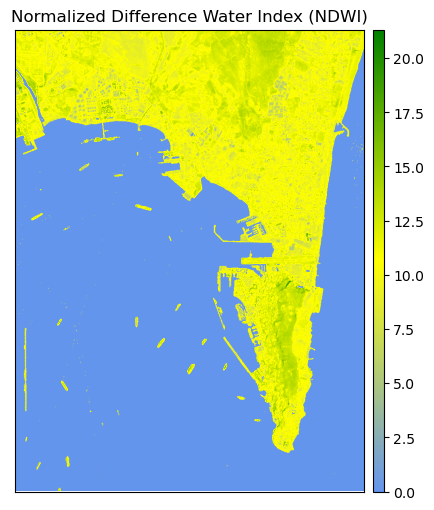

In [33]:

from matplotlib.colors import LinearSegmentedColormap

ndwi = (features_train[1] - features_train[3])/(features_train[1] + features_train[3])

norm = plt.Normalize(0, 1)
cmap = LinearSegmentedColormap.from_list('', ['cornflowerblue', 'yellow', 'green'])

title = 'Normalized Difference Water Index (NDWI)'
ep.plot_bands(ndwi, cmap=cmap, vmin=0, title=title, figsize=(6, 6))

plt.show()

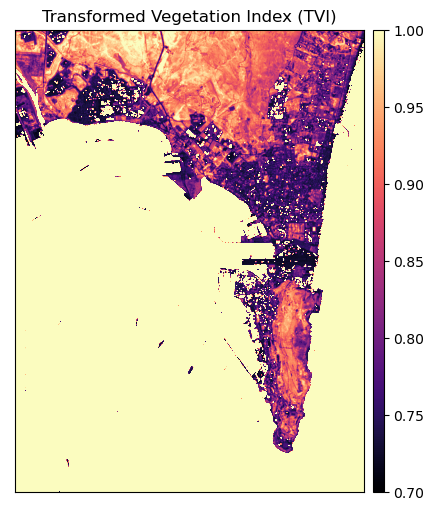

In [34]:
tvi = ((features_train[3] - features_train[2])/(features_train[3] + features_train[2]) + 0.5)**0.5

title = 'Transformed Vegetation Index (TVI)'
ep.plot_bands(tvi, cmap='magma', vmin=0.7, vmax=1, title=title, figsize=(6, 6))

plt.show()

In [35]:
## 4. Preprocessing Data

In [36]:
# reaname variables
train = train_label_data
test = df_test
del train_label_data, df_test

# optionally: load dataframes from CSV files
#train = pd.read_csv('train.csv')
#test = pd.read_csv('test.csv')

train.head()

,Class,Blue,Green,Red,NIR
0,10,0,0,0,0
1,10,1997,1982,1860,3672
2,10,1950,1906,1776,3335
3,10,1933,1886,1742,3390
4,10,2162,2035,2173,3605


In [37]:
# drop unknown classes
train = train[train['Class'] != 0]

In [38]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# rescale features
scaled_train = pd.DataFrame(MinMaxScaler().fit_transform(train), columns=train.columns)
scaled_test =  pd.DataFrame(MinMaxScaler().fit_transform(test), columns=test.columns)

X = np.array(train.drop('Class', axis=1)[::10])
y = np.array(train['Class'][::10])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, shuffle=True)

print(f'Training rows: {X_train.shape[0]}\nTesting rows: {X_test.shape[0]}')

Training rows: 67591
Testing rows: 28968


In [39]:
# class number: class name
legend_desc = ds_training_GT.GetMetadataItem('legend')
print(f'{legend_desc}')

10  Tree cover
20  Shrubland
30  Grassland
40  Cropland
50  Built-up
60  Bare/sparse vegetation
70  Snow and ice
80  Permanent water bodies
90  Herbaceous wetland
95  Mangroves
100 Moss and lichen



In [40]:
# all available labels in training dataset
classes = np.unique(train['Class']).tolist()
classes

[10, 20, 30, 40, 50, 60, 80, 90]

In [41]:
# notice label 70 (Snow and ice) is missing in the training dataset
cover_labels = ['Tree cover',               # 10
                'Shrubland',                # 20
                'Grassland',                # 30
                'Cropland',                 # 40
                'Built-up',                 # 50
                'Bare/sparse vegetation',   # 60
                #'Snow and ice'              # 70
                'Water bodies',             # 80
                'Herbaceous wetland'        # 90
               ]

# function for RGB -> HEX conversion
def hextriplet(colortuple):
    return '#' + ''.join(f'{i:02X}' for i in colortuple)

# RGB colors used in ESA manual
rgb_list = [(0,100,0),     # 10
            (255,187,34),  # 20
            (255,255,76),  # 30
            (240,150,255), # 40
            (250,0,0),     # 50
            (180,180,180), # 60
            #(240,240,240), # 70
            (0,100,200),   # 80
            (0,150,160)    # 90
           ]

# convert RGB colors to HEX codes
cover_colors = []
for i in rgb_list:
    cover_colors.append(hextriplet(i))
    
# store attributes in dataframe
df_esa = pd.DataFrame(data=zip(classes, cover_labels, cover_colors, rgb_list),
                      columns=['Class', 'Cover', 'Hex', 'RGB'])

df_esa.style.hide(axis='index')

Class,Cover,Hex,RGB
10,Tree cover,#006400,"(0, 100, 0)"
20,Shrubland,#FFBB22,"(255, 187, 34)"
30,Grassland,#FFFF4C,"(255, 255, 76)"
40,Cropland,#F096FF,"(240, 150, 255)"
50,Built-up,#FA0000,"(250, 0, 0)"
60,Bare/sparse vegetation,#B4B4B4,"(180, 180, 180)"
80,Water bodies,#0064C8,"(0, 100, 200)"
90,Herbaceous wetland,#0096A0,"(0, 150, 160)"


In [42]:
## 5. Machine Learning Classifiers

In [44]:
pip install catboost

Defaulting to user installation because normal site-packages is not writeableNote: you may need to restart the kernel to use updated packages.

  Obtaining dependency information for catboost from https://files.pythonhosted.org/packages/51/ee/aa88284e111c27ed292dbbef027838f7f4267363cc0fb8fe48f9edf83ef2/catboost-1.2.7-cp39-cp39-win_amd64.whl.metadata
  Obtaining dependency information for graphviz from https://files.pythonhosted.org/packages/00/be/d59db2d1d52697c6adc9eacaf50e8965b6345cc143f671e1ed068818d5cf/graphviz-0.20.3-py3-none-any.whl.metadata
  Obtaining dependency information for numpy<2.0,>=1.16.0 from https://files.pythonhosted.org/packages/b5/42/054082bd8220bbf6f297f982f0a8f5479fcbc55c8b511d928df07b965869/numpy-1.26.4-cp39-cp39-win_amd64.whl.metadata
     -------------------------------------- 61.0/61.0 kB 806.3 kB/s eta 0:00:00
   ---------------------------------------- 101.8/101.8 MB 2.2 MB/s eta 0:00:00
   ---------------------------------------- 15.8/15.8 MB 4.2 MB/s eta 

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [45]:
from catboost import CatBoostClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

import sklearn.metrics as metrics
from sklearn.model_selection import learning_curve

In [52]:
### 5.1. Category Boosting

In [46]:
# hyperparameter tuning
depths = [6, 8, 10]
learning_rates = [0.05, 0.1]

cb_scores = []

for depth in depths:
    for rate in learning_rates:
        cb = CatBoostClassifier(depth=depth, learning_rate=rate)
        cb.fit(X_train, y_train, verbose=False)
        cb_pred = cb.predict(X_test)
        
        cb_scores.append({'accuracy': metrics.accuracy_score(y_test, cb_pred),
                          'depth': depth,
                          'learning_rate': rate,
                         })

# get optimum hyperparameters
accuracies = [result['accuracy'] for result in cb_scores]
cb_idx = accuracies.index(max(accuracies))

print('Best score:', cb_scores[cb_idx])

Best score: {'accuracy': 0.9024785970726319, 'depth': 10, 'learning_rate': 0.05}


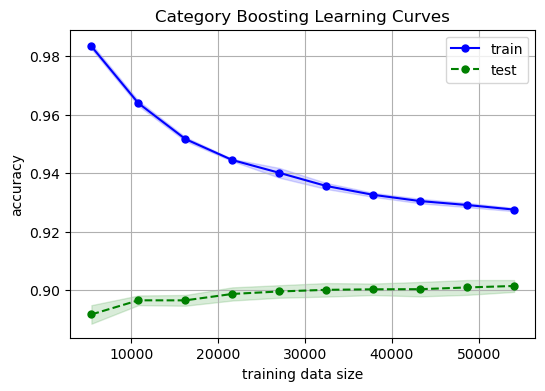

In [47]:
# generate different set sizes and get scores
train_sizes, train_scores, test_scores = learning_curve(CatBoostClassifier(depth=8, learning_rate=0.1, verbose=False),
                                                        X_train, y_train,
                                                        train_sizes=np.linspace(0.1, 1.0, 10)
                                                       )

# function for plotting learning curves
def plot_learning_curves(clf):
    # calculate training and testing mean and std
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    test_std = np.std(test_scores, axis=1)
    
    # plot learning curves
    plt.figure(figsize=(6, 4))
    
    plt.plot(train_sizes, train_mean, color='blue', marker='o', markersize=5, label='train')
    plt.fill_between(train_sizes, train_mean + train_std, train_mean - train_std, alpha=0.15, color='blue')
    plt.plot(train_sizes, test_mean, color='green', marker='o', markersize=5, linestyle='--', label='test')
    plt.fill_between(train_sizes, test_mean + test_std, test_mean - test_std, alpha=0.15, color='green')
    plt.title(f'{clf} Learning Curves')
    plt.xlabel('training data size')
    plt.ylabel('accuracy')
    plt.grid()
    plt.legend()
    plt.show()
    
plot_learning_curves(clf='Category Boosting')

In [48]:
cb = CatBoostClassifier(depth=8, learning_rate=0.1)
cb.fit(X_train, y_train, verbose=False)
cb_pred = cb.predict(X_test)

# make predictions
y_pred_cb = cb.predict(test)

# evaluation metrics
acc_cb = metrics.accuracy_score(y_test, cb_pred)
kappa_cb = metrics.cohen_kappa_score(y_test, cb_pred)

print("Accuracy: {:0.4f}\nCohen's kappa: {:0.4f}".format(acc_cb, kappa_cb))

Accuracy: 0.9020
Cohen's kappa: 0.8223


In [49]:
# extract predicted classes, colors, covers
cb_classes = np.unique(y_pred_cb).tolist()
cb_colors = df_esa.query(f'Class in {cb_classes}')['Hex'].tolist()
cb_covers = df_esa.query(f'Class in {cb_classes}')['Cover'].tolist()

# new array made of assigned color indices to predicted labels
cb_func = np.vectorize(lambda x: cb_classes.index(x))
cb_data = cb_func(y_pred_cb)

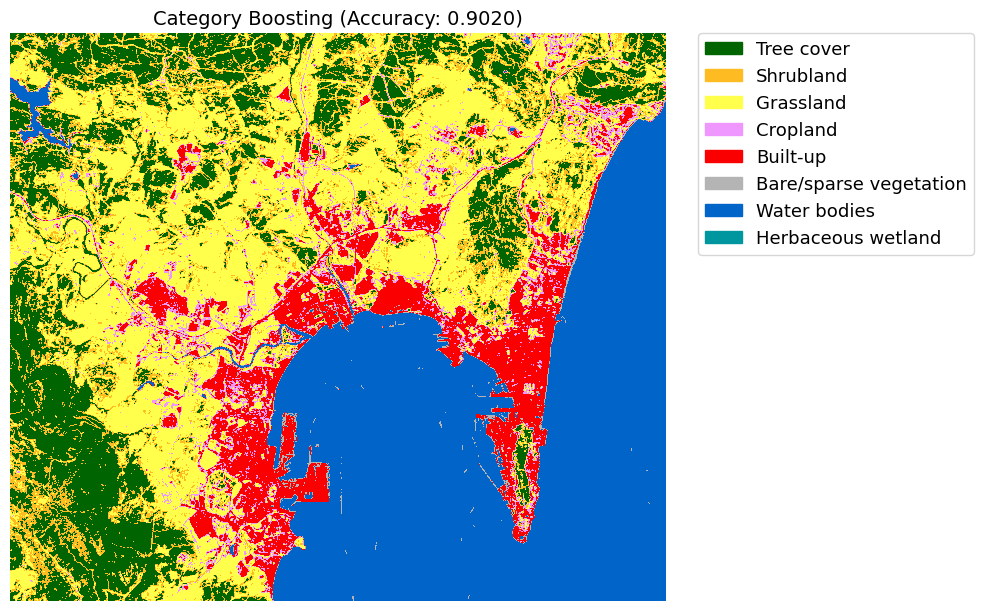

In [50]:
from matplotlib.colors import ListedColormap

cb_cmap = ListedColormap(cb_colors)

height = ds_testing.ReadAsArray().shape[2]
width = ds_testing.ReadAsArray().shape[1]

# plot predicted data
fig, ax = plt.subplots(figsize=(10, 10))
im = ax.imshow(cb_data.reshape(height, width).T, cmap=cb_cmap, vmin=0, vmax=len(cb_colors)-1)

ep.draw_legend(im_ax=im, classes=cb_classes, titles=cb_covers)
#ax.set_title('Category Boosting (Accuracy: {:.2f}%)'.format(acc_cb*100), fontsize=14)
ax.set_title('Category Boosting (Accuracy: {:.4f})'.format(acc_cb), fontsize=14)
ax.set_axis_off()

# auto adjust plot to fit figure size
plt.tight_layout()
plt.show()

In [51]:
print(metrics.classification_report(y_test, cb_pred, target_names=cover_labels))

                        precision    recall  f1-score   support

            Tree cover       0.75      0.63      0.69      1771
             Shrubland       0.59      0.57      0.58       464
             Grassland       0.72      0.74      0.73      3346
              Cropland       0.58      0.12      0.20       124
              Built-up       0.77      0.89      0.83      4265
Bare/sparse vegetation       0.65      0.25      0.37       437
          Water bodies       0.99      0.99      0.99     18508
    Herbaceous wetland       0.55      0.11      0.19        53

              accuracy                           0.90     28968
             macro avg       0.70      0.54      0.57     28968
          weighted avg       0.90      0.90      0.90     28968



In [53]:
### 5.2. Gaussian Naive Bayes

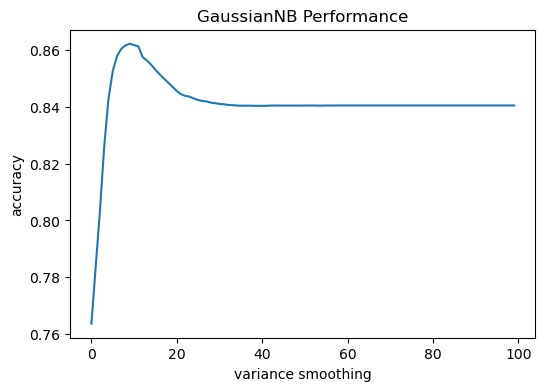

Score: 0.8622 for variance = 0.15199110829529336


In [54]:
# hyperparameter tuning
variances = np.logspace(0, -9, num=100)

nb_scores = []

for var in variances:
    nb = GaussianNB(var_smoothing=var)
    nb.fit(X_train, y_train)
    nb_pred = nb.predict(X_test)
    
    nb_scores.append(metrics.accuracy_score(y_test, nb_pred))

# get optimum variance
var_idx = nb_scores.index(max(nb_scores))
var = variances[var_idx]

# plot results
plt.figure(figsize=(6, 4))   
plt.plot(nb_scores)
plt.title('GaussianNB Performance')
plt.xlabel('variance smoothing')
plt.ylabel('accuracy')
#plt.grid()
plt.show()

print('Score: {:0.4f} for variance = {}'.format(max(nb_scores), var))

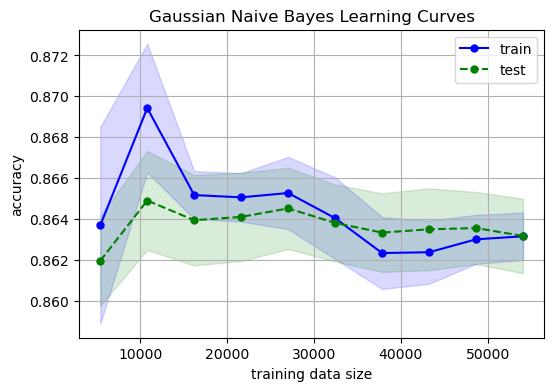

In [55]:
# generate different set sizes and get scores
train_sizes, train_scores, test_scores = learning_curve(GaussianNB(var_smoothing=0.15199110829529336),
                                                        X_train, y_train,
                                                        train_sizes=np.linspace(0.1, 1.0, 10)
                                                       )

plot_learning_curves(clf='Gaussian Naive Bayes')

In [56]:
nb = GaussianNB(var_smoothing=0.15199110829529336)
nb.fit(X_train, y_train)
nb_pred = nb.predict(X_test)

# make predictions
y_pred_nb = nb.predict(test)

# evaluation metrics
acc_nb = metrics.accuracy_score(y_test, nb_pred)
kappa_nb = metrics.cohen_kappa_score(y_test, nb_pred)

print("Accuracy: {:0.4f}\nCohen's kappa: {:0.4f}".format(acc_nb, kappa_nb))

Accuracy: 0.8622
Cohen's kappa: 0.7454


In [57]:
# extract predicted classes, colors, covers
nb_classes = np.unique(y_pred_nb).tolist()
nb_colors = df_esa.query(f'Class in {nb_classes}')['Hex'].tolist()
nb_covers = df_esa.query(f'Class in {nb_classes}')['Cover'].tolist()

# new array made of assigned color indices to predicted labels
nb_func = np.vectorize(lambda x: nb_classes.index(x))
nb_data = nb_func(y_pred_nb)

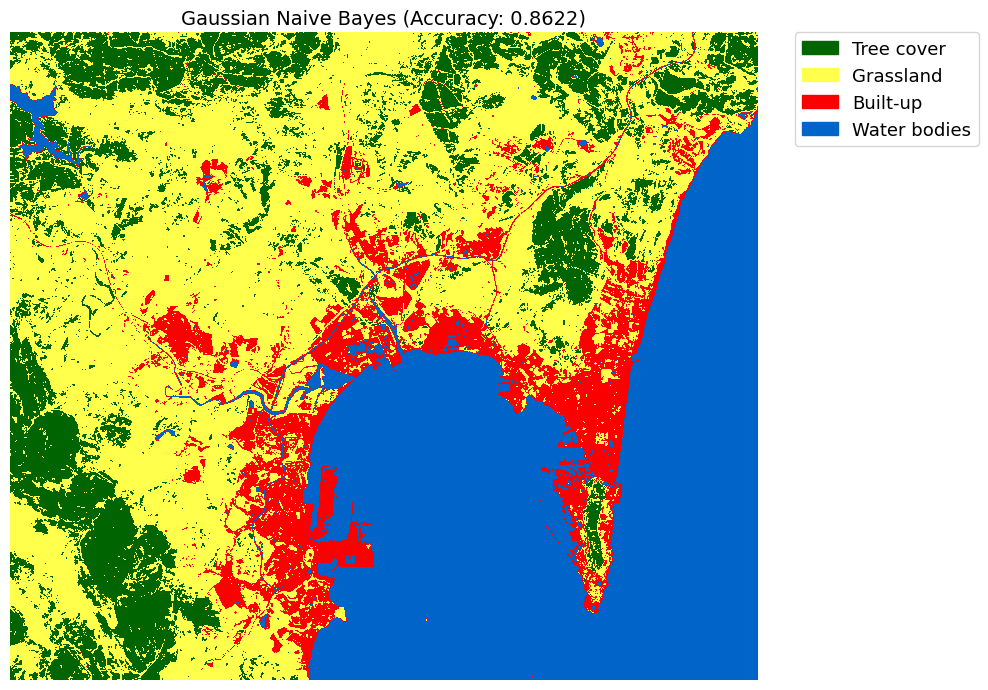

In [58]:
nb_cmap = ListedColormap(nb_colors)

height = ds_testing.ReadAsArray().shape[2]
width = ds_testing.ReadAsArray().shape[1]

# plot predicted data
fig, ax = plt.subplots(figsize=(10, 10))
im = ax.imshow(nb_data.reshape(height, width).T, cmap=nb_cmap, vmin=0, vmax=len(nb_colors)-1)

ep.draw_legend(im_ax=im, classes=nb_classes, titles=nb_covers)
#ax.set_title('Gaussian Naive Bayes (Accuracy: {:.2f}%)'.format(acc_nb*100), fontsize=14)
ax.set_title('Gaussian Naive Bayes (Accuracy: {:.4f})'.format(acc_nb), fontsize=14)
ax.set_axis_off()

# auto adjust plot to fit figure size
plt.tight_layout()
plt.show()

In [59]:
print(metrics.classification_report(y_test, nb_pred, target_names=cover_labels))

                        precision    recall  f1-score   support

            Tree cover       0.51      0.78      0.62      1771
             Shrubland       0.00      0.00      0.00       464
             Grassland       0.67      0.62      0.64      3346
              Cropland       0.00      0.00      0.00       124
              Built-up       0.77      0.75      0.76      4265
Bare/sparse vegetation       0.00      0.00      0.00       437
          Water bodies       0.96      0.99      0.98     18508
    Herbaceous wetland       0.00      0.00      0.00        53

              accuracy                           0.86     28968
             macro avg       0.36      0.39      0.37     28968
          weighted avg       0.84      0.86      0.85     28968



In [60]:
### 5.3.  k-Nearest Neighbors

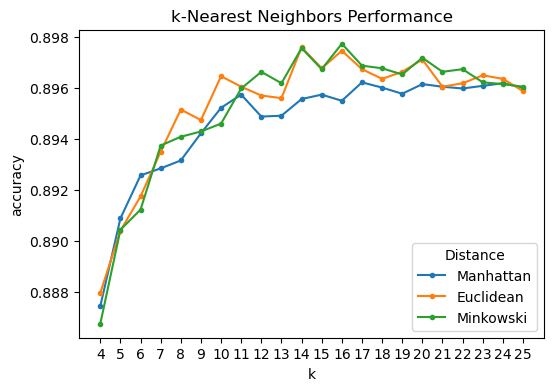

Manhattan: 0.8962 for k = 17
Euclidean: 0.8976 for k = 14
Minkowski: 0.8976 for k = 16


In [61]:
# hyperparameter tuning
n_neighbors = range(4, 26)
distances = [1, 2, 5]      # 1 - Manhattan, 2 - Euclidean, 5 - Minkowski

manhattan_scores = []
euclidean_scores = []
minkowski_scores = []

for k in n_neighbors:
    for p in distances:
        knn = KNeighborsClassifier(n_neighbors=k, p=p)
        knn.fit(X_train, y_train)
        knn_pred = knn.predict(X_test)
        
        if p == 1:
            manhattan_scores.append(metrics.accuracy_score(y_test, knn_pred))
        elif p == 2:
            euclidean_scores.append(metrics.accuracy_score(y_test, knn_pred))
        elif p == 5:
            minkowski_scores.append(metrics.accuracy_score(y_test, knn_pred))

# get optimum k for each distance
man_k = manhattan_scores.index(max(manhattan_scores)) + 4
euc_k = euclidean_scores.index(max(euclidean_scores)) + 4
min_k = minkowski_scores.index(max(minkowski_scores)) + 4

# plot results
plt.figure(figsize=(6, 4))   
plt.plot(range(4, 26), manhattan_scores, marker='.', label='Manhattan')
plt.plot(range(4, 26), euclidean_scores, marker='.', label='Euclidean')
plt.plot(range(4, 26), minkowski_scores, marker='.', label='Minkowski')
plt.title('k-Nearest Neighbors Performance')
plt.xlabel('k')
plt.xticks(range(4, 26))
plt.ylabel('accuracy')
plt.legend(title='Distance')
#plt.grid()
plt.show()

print('Manhattan: {:0.4f} for k = {}'.format(max(manhattan_scores), man_k))
print('Euclidean: {:0.4f} for k = {}'.format(max(euclidean_scores), euc_k))
print('Minkowski: {:0.4f} for k = {}'.format(max(euclidean_scores), min_k))

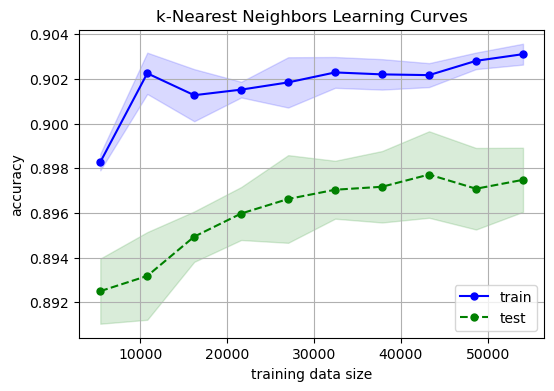

In [62]:
# generate different set sizes and get scores
train_sizes, train_scores, test_scores = learning_curve(KNeighborsClassifier(n_neighbors=25, p=1),
                                                        X_train, y_train,
                                                        train_sizes=np.linspace(0.1, 1.0, 10)
                                                       )

plot_learning_curves(clf='k-Nearest Neighbors')

In [63]:
knn = KNeighborsClassifier(n_neighbors=25, p=1)
knn.fit(X_train, y_train)
knn_pred = knn.predict(X_test)

# make predictions
y_pred_knn = knn.predict(test)

# evaluation metrics
acc_knn = metrics.accuracy_score(y_test, knn_pred)
kappa_knn = metrics.cohen_kappa_score(y_test, knn_pred)

print("Accuracy: {:0.4f}\nCohen's kappa: {:0.4f}".format(acc_knn, kappa_knn))

Accuracy: 0.8960
Cohen's kappa: 0.8116


In [64]:
# extract predicted classes, colors, covers
knn_classes = np.unique(y_pred_knn).tolist()
knn_colors = df_esa.query(f'Class in {knn_classes}')['Hex'].tolist()
knn_covers = df_esa.query(f'Class in {knn_classes}')['Cover'].tolist()

# new array made of assigned color indices to predicted labels
knn_func = np.vectorize(lambda x: knn_classes.index(x))
knn_data = knn_func(y_pred_knn)

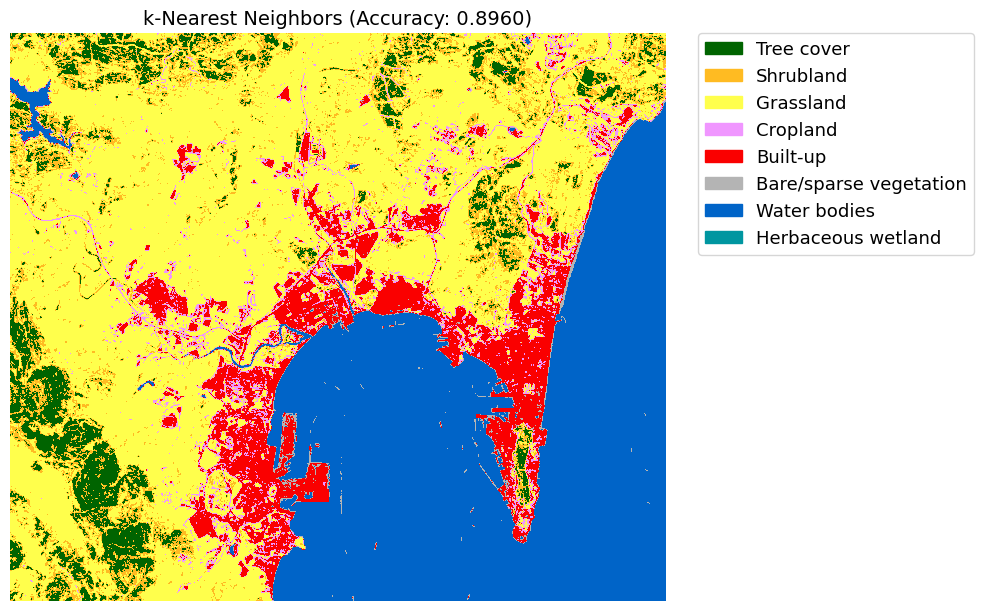

In [65]:
knn_cmap = ListedColormap(knn_colors)

height = ds_testing.ReadAsArray().shape[2]
width = ds_testing.ReadAsArray().shape[1]

# plot predicted data
fig, ax = plt.subplots(figsize=(10, 10))
im = ax.imshow(knn_data.reshape(height, width).T, cmap=knn_cmap, vmin=0, vmax=len(knn_colors)-1)

ep.draw_legend(im_ax=im, classes=knn_classes, titles=knn_covers)
#ax.set_title('k-Nearest Neighbors (Accuracy: {:.2f}%)'.format(acc_knn*100), fontsize=14)
ax.set_title('k-Nearest Neighbors (Accuracy: {:.4f})'.format(acc_knn), fontsize=14)
ax.set_axis_off()

# auto adjust plot to fit figure size
plt.tight_layout()
plt.show()

In [66]:
print(metrics.classification_report(y_test, knn_pred, target_names=cover_labels))

                        precision    recall  f1-score   support

            Tree cover       0.74      0.59      0.65      1771
             Shrubland       0.55      0.52      0.53       464
             Grassland       0.68      0.77      0.72      3346
              Cropland       0.52      0.10      0.16       124
              Built-up       0.77      0.87      0.82      4265
Bare/sparse vegetation       0.60      0.22      0.32       437
          Water bodies       0.99      0.99      0.99     18508
    Herbaceous wetland       0.00      0.00      0.00        53

              accuracy                           0.90     28968
             macro avg       0.61      0.51      0.53     28968
          weighted avg       0.89      0.90      0.89     28968



In [67]:
### 5.4.  Random Forest

In [68]:
# hyperparameter tuning
n_estimators = [100, 150, 200]
max_depth_values = [None, 2, 3, 4, 5]

rf_scores = []

for depth in max_depth_values:
    for n in n_estimators:
        rf = RandomForestClassifier(max_depth=depth, n_estimators=n)
        rf.fit(X_train, y_train)
        rf_pred = rf.predict(X_test)
        
        rf_scores.append({'accuracy': metrics.accuracy_score(y_test, rf_pred),
                          'max_depth': depth,
                          'n_estimators': n,
                         })

# get optimum hyperparameters
accuracies = [result['accuracy'] for result in rf_scores]
rf_idx = accuracies.index(max(accuracies))

print('Best score:', rf_scores[rf_idx])

Best score: {'accuracy': 0.899026512013256, 'max_depth': None, 'n_estimators': 200}


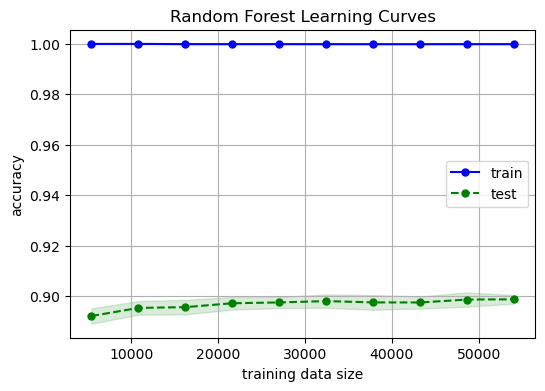

In [69]:
# generate different set sizes and get scores
train_sizes, train_scores, test_scores = learning_curve(RandomForestClassifier(max_depth=None, n_estimators=200),
                                                        X_train, y_train,
                                                        train_sizes=np.linspace(0.1, 1.0, 10)
                                                       )

plot_learning_curves(clf='Random Forest')

In [70]:
rf = RandomForestClassifier(max_depth=None, n_estimators=200)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

# make predictions
y_pred_rf = rf.predict(test)

# evaluation metrics
acc_rf = metrics.accuracy_score(y_test, rf_pred)
kappa_rf = metrics.cohen_kappa_score(y_test, rf_pred)

print("Accuracy: {:0.4f}\nCohen's kappa: {:0.4f}".format(acc_rf, kappa_rf))

Accuracy: 0.8996
Cohen's kappa: 0.8179


In [71]:
# extract predicted classes, colors, covers
rf_classes = np.unique(y_pred_rf).tolist()
rf_colors = df_esa.query(f'Class in {rf_classes}')['Hex'].tolist()
rf_covers = df_esa.query(f'Class in {rf_classes}')['Cover'].tolist()

# new array made of assigned color indices to predicted labels
rf_func = np.vectorize(lambda x: rf_classes.index(x))
rf_data = rf_func(y_pred_rf)

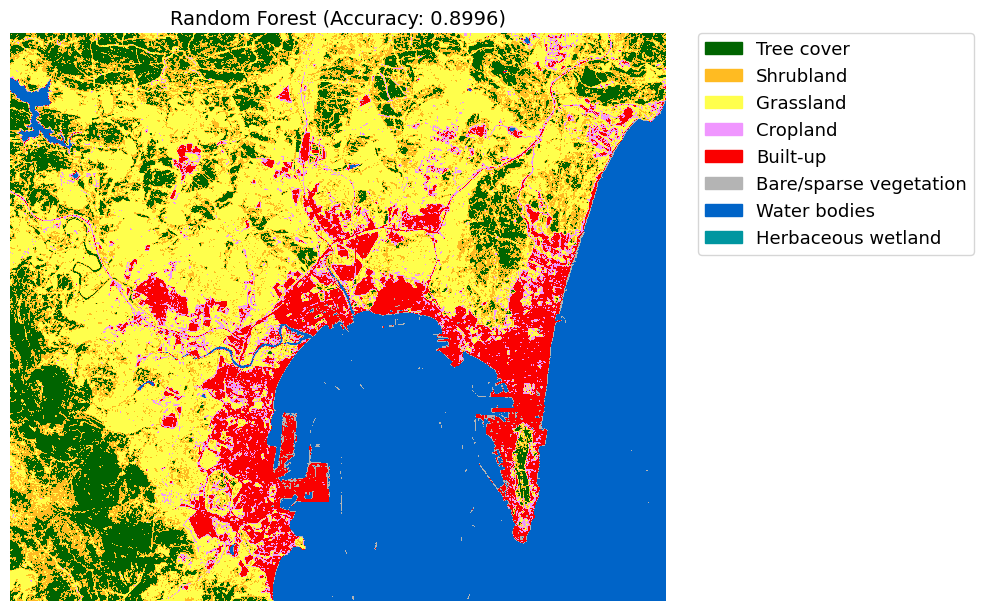

In [72]:
rf_cmap = ListedColormap(rf_colors)

height = ds_testing.ReadAsArray().shape[2]
width = ds_testing.ReadAsArray().shape[1]

# plot predicted data
fig, ax = plt.subplots(figsize=(10, 10))
im = ax.imshow(rf_data.reshape(height, width).T, cmap=rf_cmap, vmin=0, vmax=len(rf_colors)-1)

ep.draw_legend(im_ax=im, classes=rf_classes, titles=rf_covers)
#ax.set_title('Random Forest (Accuracy: {:.2f}%)'.format(acc_rf*100), fontsize=14)
ax.set_title('Random Forest (Accuracy: {:.4f})'.format(acc_rf), fontsize=14)
ax.set_axis_off()

# auto adjust plot to fit figure size
plt.tight_layout()
plt.show()

In [73]:
print(metrics.classification_report(y_test, rf_pred, target_names=cover_labels))

                        precision    recall  f1-score   support

            Tree cover       0.73      0.65      0.69      1771
             Shrubland       0.60      0.56      0.58       464
             Grassland       0.70      0.73      0.72      3346
              Cropland       0.58      0.17      0.26       124
              Built-up       0.78      0.88      0.83      4265
Bare/sparse vegetation       0.62      0.25      0.35       437
          Water bodies       0.99      0.99      0.99     18508
    Herbaceous wetland       0.13      0.04      0.06        53

              accuracy                           0.90     28968
             macro avg       0.64      0.53      0.56     28968
          weighted avg       0.90      0.90      0.90     28968



In [74]:
### 5.4.  Classifier Comparison

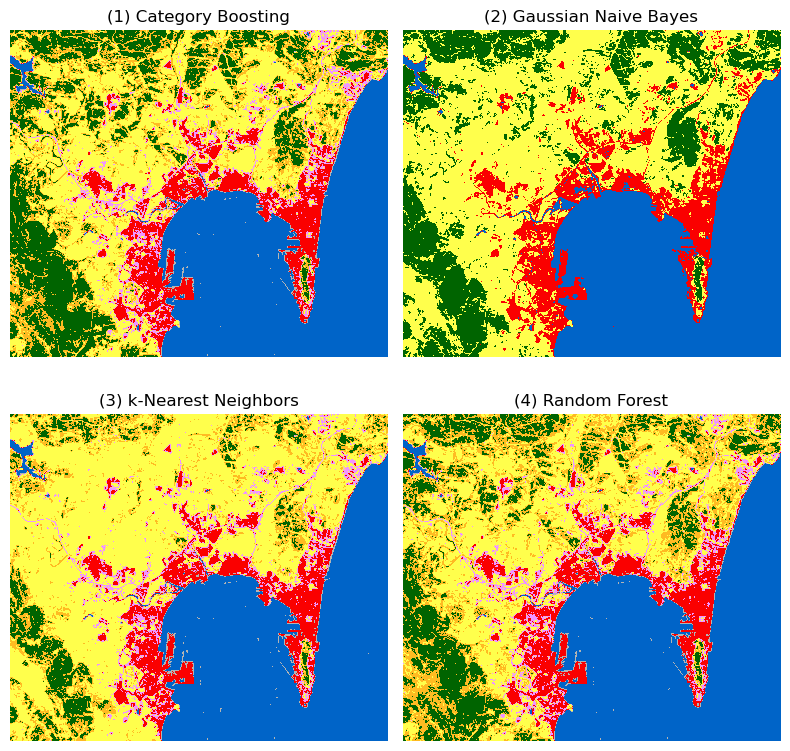

In [75]:
# visualize all figures in one
fig, axs = plt.subplots(2, 2, figsize=(8, 8))

axs[0, 0].imshow(cb_data.reshape(height, width).T, cmap=cb_cmap, vmin=0, vmax=len(cb_colors)-1)
axs[0, 0].set_title('(1) Category Boosting')
axs[0, 0].set_axis_off()

axs[0, 1].imshow(nb_data.reshape(height, width).T, cmap=nb_cmap, vmin=0, vmax=len(nb_colors)-1)
axs[0, 1].set_title('(2) Gaussian Naive Bayes')
axs[0, 1].set_axis_off()

axs[1, 0].imshow(knn_data.reshape(height, width).T, cmap=knn_cmap, vmin=0, vmax=len(knn_colors)-1)
axs[1, 0].set_title('(3) k-Nearest Neighbors')
axs[1, 0].set_axis_off()

axs[1, 1].imshow(rf_data.reshape(height, width).T, cmap=rf_cmap, vmin=0, vmax=len(rf_colors)-1)
axs[1, 1].set_title('(4) Random Forest')
axs[1, 1].set_axis_off()

plt.tight_layout()
plt.show()

In [76]:
# evaluation metrics
pd.DataFrame([[acc_cb, acc_nb, acc_knn, acc_rf],
              [kappa_cb, kappa_nb, kappa_knn, kappa_rf]],
             index=['Accuracy', "Cohen's kappa"],
             columns=['CatBoost', 'GaussianNB', 'k-Nearest Neighbors', 'RandomForest']).round(4)

,CatBoost,GaussianNB,k-Nearest Neighbors,RandomForest
Accuracy,0.9020,0.8622,0.8960,0.8996
Cohen's kappa,0.8223,0.7454,0.8116,0.8179


In [77]:
# testing image resolution
img_res = height * width

# function for cover areas in %
def count_areas(lst, pred):
    unique, counts = np.unique(pred, return_counts=True)
    for i in counts:
        lst.append((100 * i)/img_res)
    #lst.append(sum(lst))
    
cb_areas = []
nb_areas = []
knn_areas = []
rf_areas = []

list_area = [cb_areas, nb_areas, knn_areas, rf_areas]
list_pred = [y_pred_cb, y_pred_nb, y_pred_knn, y_pred_rf]

for i, j in zip(list_area, list_pred):
    count_areas(lst=i, pred=j)

# insert missing covers for GaussianNB list
nb_areas.insert(1, 0)
nb_areas.insert(3, 0)
nb_areas.insert(5, 0)
nb_areas.insert(7, 0)

In [78]:
# percentage of covers for each classifier
pd.DataFrame([cb_areas, nb_areas, knn_areas, rf_areas],
             index=['CatBoost', 'GaussianNB', 'k-Nearest Neighbors', 'RandomForest'],
             columns=cover_labels).round(2)

,Tree cover,Shrubland,Grassland,Cropland,Built-up,Bare/sparse vegetation,Water bodies,Herbaceous wetland
CatBoost,19.01,0.00,38.11,0.11,12.60,0.32,29.80,0.04
GaussianNB,13.50,0.00,45.02,0.00,11.01,0.00,30.47,0.00
k-Nearest Neighbors,7.79,0.12,50.05,0.00,12.00,0.36,29.68,0.00
RandomForest,17.00,0.00,39.99,0.04,12.82,0.30,29.80,0.05


In [80]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    cohen_kappa_score
)
import seaborn as sns
import matplotlib.pyplot as plt

In [85]:
### 6.1.  Confusion Matrix (Random Forest)

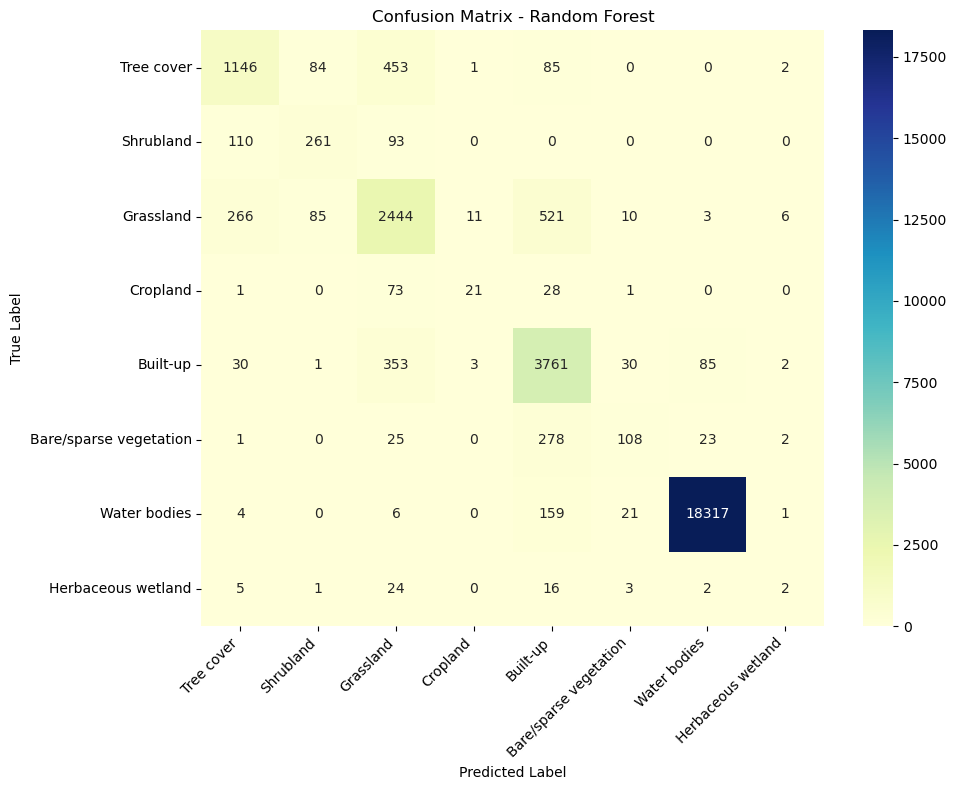

In [84]:
class_names = [
    "Tree cover",
    "Shrubland",
    "Grassland",
    "Cropland",
    "Built-up",
    "Bare/sparse vegetation",
    "Water bodies",
    "Herbaceous wetland"
]

# Compute confusion matrix
cm_rf = confusion_matrix(y_test, rf_pred)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [86]:
print("Classification Report - Random Forest\n")
print(classification_report(y_test, rf_pred, target_names=class_names))

Classification Report - Random Forest

                        precision    recall  f1-score   support

            Tree cover       0.73      0.65      0.69      1771
             Shrubland       0.60      0.56      0.58       464
             Grassland       0.70      0.73      0.72      3346
              Cropland       0.58      0.17      0.26       124
              Built-up       0.78      0.88      0.83      4265
Bare/sparse vegetation       0.62      0.25      0.35       437
          Water bodies       0.99      0.99      0.99     18508
    Herbaceous wetland       0.13      0.04      0.06        53

              accuracy                           0.90     28968
             macro avg       0.64      0.53      0.56     28968
          weighted avg       0.90      0.90      0.90     28968



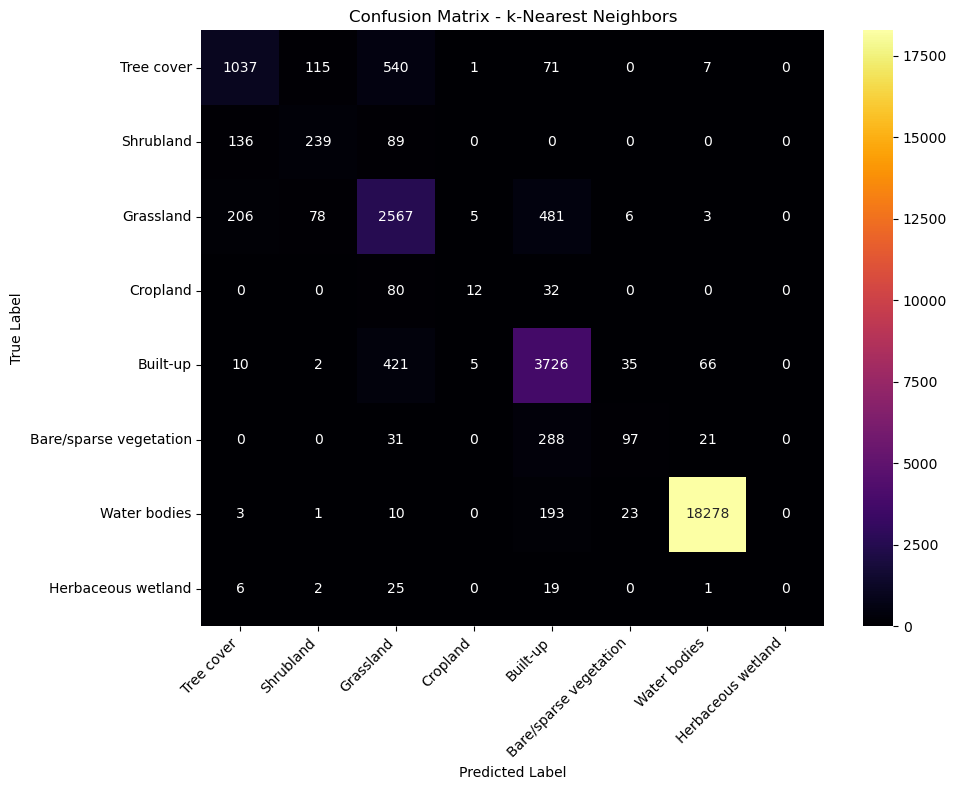

In [94]:
cm_knn = confusion_matrix(y_test, knn_pred)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='inferno',
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix - k-Nearest Neighbors")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [88]:
print("Classification Report - k-Nearest Neighbors\n")
print(classification_report(y_test, knn_pred, target_names=class_names))

Classification Report - k-Nearest Neighbors

                        precision    recall  f1-score   support

            Tree cover       0.74      0.59      0.65      1771
             Shrubland       0.55      0.52      0.53       464
             Grassland       0.68      0.77      0.72      3346
              Cropland       0.52      0.10      0.16       124
              Built-up       0.77      0.87      0.82      4265
Bare/sparse vegetation       0.60      0.22      0.32       437
          Water bodies       0.99      0.99      0.99     18508
    Herbaceous wetland       0.00      0.00      0.00        53

              accuracy                           0.90     28968
             macro avg       0.61      0.51      0.53     28968
          weighted avg       0.89      0.90      0.89     28968



In [89]:
cm = cm_knn.astype(np.float32)
user_acc = np.diag(cm) / np.sum(cm, axis=0)  # Precision (Predicted)
prod_acc = np.diag(cm) / np.sum(cm, axis=1)  # Recall (Actual)

print("\nPer-Class Accuracies:")
for i, cls in enumerate(class_names):
    print(f"{cls}: User's Accuracy = {user_acc[i]*100:.2f}%, Producer's Accuracy = {prod_acc[i]*100:.2f}%")



Per-Class Accuracies:
Tree cover: User's Accuracy = 74.18%, Producer's Accuracy = 58.55%
Shrubland: User's Accuracy = 54.69%, Producer's Accuracy = 51.51%
Grassland: User's Accuracy = 68.22%, Producer's Accuracy = 76.72%
Cropland: User's Accuracy = 52.17%, Producer's Accuracy = 9.68%
Built-up: User's Accuracy = 77.46%, Producer's Accuracy = 87.36%
Bare/sparse vegetation: User's Accuracy = 60.25%, Producer's Accuracy = 22.20%
Water bodies: User's Accuracy = 99.47%, Producer's Accuracy = 98.76%
Herbaceous wetland: User's Accuracy = nan%, Producer's Accuracy = 0.00%


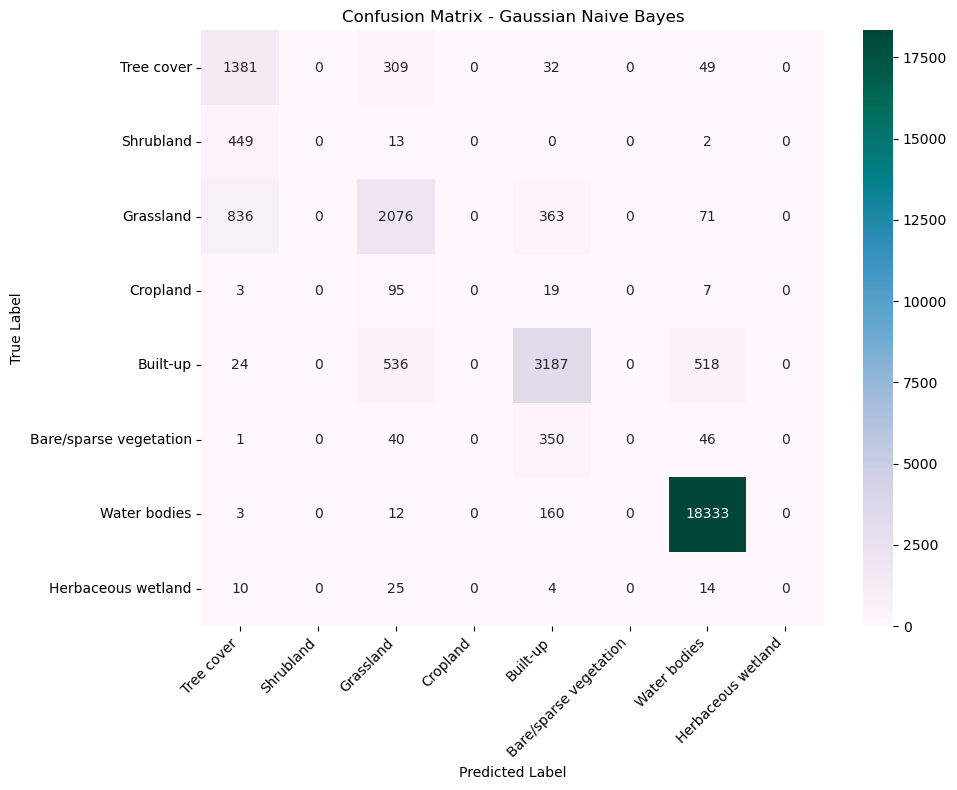

In [93]:
cm_nb = confusion_matrix(y_test, nb_pred)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='PuBuGn',
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix - Gaussian Naive Bayes")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [91]:
print("Classification Report - Gaussian Naive Bayes\n")
print(classification_report(y_test, nb_pred, target_names=class_names))

Classification Report - Gaussian Naive Bayes

                        precision    recall  f1-score   support

            Tree cover       0.51      0.78      0.62      1771
             Shrubland       0.00      0.00      0.00       464
             Grassland       0.67      0.62      0.64      3346
              Cropland       0.00      0.00      0.00       124
              Built-up       0.77      0.75      0.76      4265
Bare/sparse vegetation       0.00      0.00      0.00       437
          Water bodies       0.96      0.99      0.98     18508
    Herbaceous wetland       0.00      0.00      0.00        53

              accuracy                           0.86     28968
             macro avg       0.36      0.39      0.37     28968
          weighted avg       0.84      0.86      0.85     28968



In [92]:
cm = cm_nb.astype(np.float32)
user_acc = np.diag(cm) / np.sum(cm, axis=0)  # Precision
prod_acc = np.diag(cm) / np.sum(cm, axis=1)  # Recall

print("\nPer-Class Accuracies:")
for i, cls in enumerate(class_names):
    print(f"{cls}: User's Accuracy = {user_acc[i]*100:.2f}%, Producer's Accuracy = {prod_acc[i]*100:.2f}%")



Per-Class Accuracies:
Tree cover: User's Accuracy = 51.02%, Producer's Accuracy = 77.98%
Shrubland: User's Accuracy = nan%, Producer's Accuracy = 0.00%
Grassland: User's Accuracy = 66.84%, Producer's Accuracy = 62.04%
Cropland: User's Accuracy = nan%, Producer's Accuracy = 0.00%
Built-up: User's Accuracy = 77.45%, Producer's Accuracy = 74.72%
Bare/sparse vegetation: User's Accuracy = nan%, Producer's Accuracy = 0.00%
Water bodies: User's Accuracy = 96.29%, Producer's Accuracy = 99.05%
Herbaceous wetland: User's Accuracy = nan%, Producer's Accuracy = 0.00%


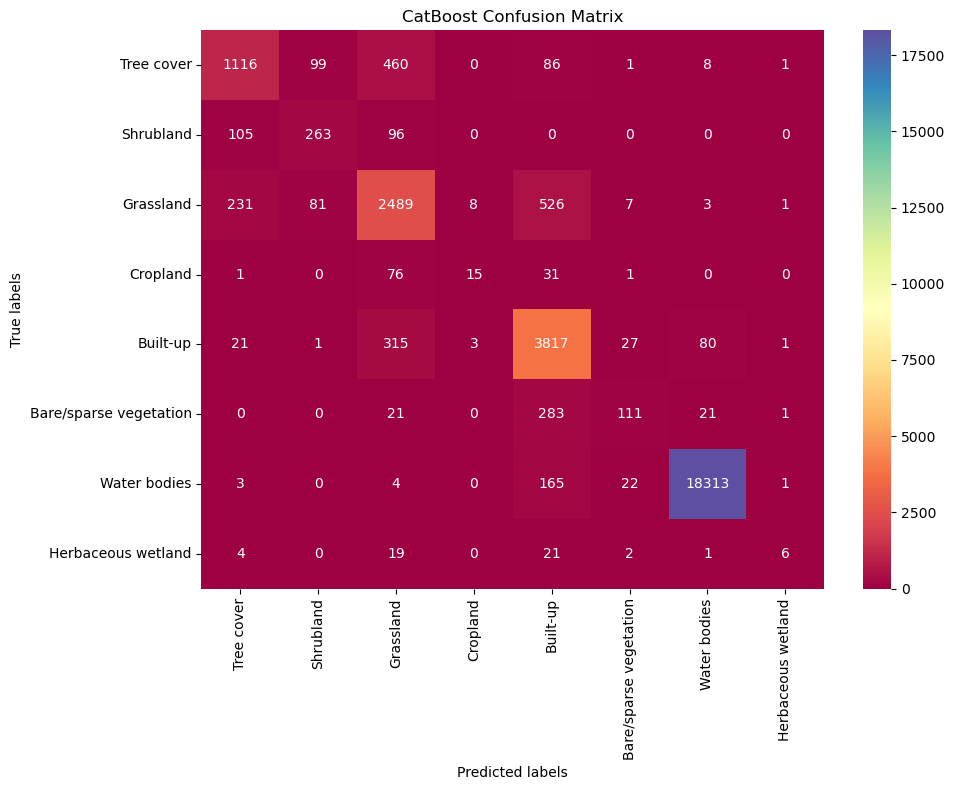

In [96]:
cb_cm = confusion_matrix(y_test, cb_pred)

# Plot it with seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(cb_cm, annot=True, fmt='d', cmap='Spectral', 
            xticklabels=class_names, 
            yticklabels=class_names)
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('CatBoost Confusion Matrix')
plt.tight_layout()
plt.show()